# Chapter 37 — Track Refinement and Gap Closing

This notebook refines Chapter 36 tracks by removing weak fragments and reconnecting broken trajectories with motion-aware gap closing.

**Inputs**
- `chapter36_filtered_detections.csv`
- `chapter36_filtered_track_nodes.csv`
- `chapter36_filtered_track_edges.csv`
- `chapter36_filtered_track_summary.csv`

**Main outputs**
- `chapter37_refined_track_nodes.csv`
- `chapter37_refined_track_edges.csv`
- `chapter37_refined_track_summary.csv`
- `chapter37_gap_closing_links.csv`


In [1]:
!pip install -q zarr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 34.5 MB/s eta 0:00:00


In [2]:
from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from IPython.display import display

In [3]:
@dataclass(frozen=True)
class RefinementConfig:
    sample_id: str = "44b6_12dfb391"
    z_scale: float = 1.625
    y_scale: float = 0.40625
    x_scale: float = 0.40625
    minimum_fragment_length: int = 2
    maximum_gap: int = 3
    maximum_gap_distance: float = 8.0
    velocity_change_weight: float = 0.50
    rank_penalty_weight: float = 0.20
    pred_dist_penalty_weight: float = 0.20
    node_match_radius: float = 6.0

CONFIG = RefinementConfig()
print(CONFIG)

RefinementConfig(sample_id='44b6_12dfb391', z_scale=1.625, y_scale=0.40625, x_scale=0.40625, minimum_fragment_length=2, maximum_gap=3, maximum_gap_distance=8.0, velocity_change_weight=0.5, rank_penalty_weight=0.2, pred_dist_penalty_weight=0.2, node_match_radius=6.0)


## Step 1 — Locate and Load Chapter 36 Outputs

In [4]:
from pathlib import Path
import pandas as pd
from IPython.display import display

def find_file(filename: str) -> Path:
    # First check the Chapter 36 dataset directly
    chapter36_dir = Path(
        "/kaggle/input/datasets/emailchrismathews/data36"
    )

    path = chapter36_dir / filename
    if path.exists():
        return path

    # Fallback to the original search
    roots = [
        Path("/kaggle/working"),
        Path("/kaggle/input"),
        Path("."),
    ]

    for root in roots:
        candidate = root / filename
        if candidate.exists():
            return candidate

    matches = []
    for root in roots:
        if root.exists():
            matches.extend(root.rglob(filename))

    if matches:
        return sorted(matches, key=lambda p: len(str(p)))[0]

    raise FileNotFoundError(
        f"Could not find {filename}. Attach the Chapter 36 outputs."
    )


paths = {
    name: find_file(name)
    for name in [
        "chapter36_filtered_detections.csv",
        "chapter36_filtered_track_nodes.csv",
        "chapter36_filtered_track_edges.csv",
        "chapter36_filtered_track_summary.csv",
    ]
}

for k, v in paths.items():
    print(f"{k}: {v}")

filtered_detections_df = pd.read_csv(
    paths["chapter36_filtered_detections.csv"]
)

filtered_track_nodes_df = pd.read_csv(
    paths["chapter36_filtered_track_nodes.csv"]
)

filtered_track_edges_df = pd.read_csv(
    paths["chapter36_filtered_track_edges.csv"]
)

filtered_track_summary_df = pd.read_csv(
    paths["chapter36_filtered_track_summary.csv"]
)

print(
    "detections",
    len(filtered_detections_df),
    "nodes",
    len(filtered_track_nodes_df),
    "edges",
    len(filtered_track_edges_df),
)

display(filtered_track_nodes_df.head())

chapter36_filtered_detections.csv: /kaggle/input/datasets/emailchrismathews/data36/chapter36_filtered_detections.csv
chapter36_filtered_track_nodes.csv: /kaggle/input/datasets/emailchrismathews/data36/chapter36_filtered_track_nodes.csv
chapter36_filtered_track_edges.csv: /kaggle/input/datasets/emailchrismathews/data36/chapter36_filtered_track_edges.csv
chapter36_filtered_track_summary.csv: /kaggle/input/datasets/emailchrismathews/data36/chapter36_filtered_track_summary.csv
detections 5000 nodes 5000 edges 2971


,track_id,detection_id,t,z,y,x,z_physical,y_physical,x_physical,rank_position,pred_dist
0,6,chapter34_t0_6,0,41.0,130.0,135.0,66.625,52.81250,54.84375,7,8.838406
1,28,chapter34_t0_28,0,22.0,190.0,59.0,35.750,77.18750,23.96875,29,11.861735
2,32,chapter34_t0_32,0,41.0,121.0,127.0,66.625,49.15625,51.59375,33,12.491119
3,34,chapter34_t0_34,0,38.0,130.0,133.0,61.750,52.81250,54.03125,35,12.895166
4,10,chapter34_t0_10,0,38.0,192.0,91.0,61.750,78.00000,36.96875,11,9.440424


## Step 2 — Prepare Physical Coordinates

In [5]:
def ensure_physical_coordinates(df, config=CONFIG):
    out=df.copy()
    if 'z_physical' not in out: out['z_physical']=out['z'].astype(float)*config.z_scale
    if 'y_physical' not in out: out['y_physical']=out['y'].astype(float)*config.y_scale
    if 'x_physical' not in out: out['x_physical']=out['x'].astype(float)*config.x_scale
    return out

filtered_track_nodes_df=ensure_physical_coordinates(filtered_track_nodes_df)


## Step 3 — Remove Short Track Fragments

In [6]:
def remove_short_fragments(nodes, edges, minimum_length):
    lengths=nodes.groupby('track_id').size()
    keep=set(lengths[lengths>=minimum_length].index)
    kept_nodes=nodes[nodes.track_id.isin(keep)].copy().reset_index(drop=True)
    kept_ids=set(kept_nodes.detection_id)
    kept_edges=edges[
        edges.source_detection_id.isin(kept_ids) & edges.target_detection_id.isin(kept_ids)
    ].copy().reset_index(drop=True) if not edges.empty else edges.copy()
    return kept_nodes,kept_edges

clean_nodes_df,clean_edges_df=remove_short_fragments(
    filtered_track_nodes_df,filtered_track_edges_df,CONFIG.minimum_fragment_length)
print('clean nodes',len(clean_nodes_df),'clean edges',len(clean_edges_df),'tracks',clean_nodes_df.track_id.nunique())

clean nodes 4642 clean edges 2971 tracks 982


## Step 4 — Build Track Endpoint Descriptors

In [7]:
def endpoint_velocity(points,times,at_end):
    if len(points)<2: return np.zeros(3,dtype=np.float32)
    a,b=(-2,-1) if at_end else (0,1)
    dt=max(int(times[b]-times[a]),1)
    return ((points[b]-points[a])/dt).astype(np.float32)

def build_endpoint_table(nodes):
    rows=[]
    for track_id,g in nodes.groupby('track_id',sort=True):
        g=g.sort_values('t').reset_index(drop=True)
        pts=g[['z_physical','y_physical','x_physical']].to_numpy(np.float32)
        ts=g.t.to_numpy(np.int32)
        sv=endpoint_velocity(pts,ts,False); ev=endpoint_velocity(pts,ts,True)
        rows.append(dict(track_id=int(track_id),start_t=int(ts[0]),end_t=int(ts[-1]),num_detections=len(g),
            start_z=pts[0,0],start_y=pts[0,1],start_x=pts[0,2],end_z=pts[-1,0],end_y=pts[-1,1],end_x=pts[-1,2],
            start_vz=sv[0],start_vy=sv[1],start_vx=sv[2],end_vz=ev[0],end_vy=ev[1],end_vx=ev[2],
            mean_rank=float(g.rank_position.mean()),mean_pred_dist=float(g.pred_dist.mean())))
    return pd.DataFrame(rows)

endpoint_df=build_endpoint_table(clean_nodes_df)
display(endpoint_df.sort_values('num_detections',ascending=False).head(20))

,track_id,start_t,end_t,num_detections,start_z,start_y,start_x,end_z,end_y,end_x,start_vz,start_vy,start_vx,end_vz,end_vy,end_vx,mean_rank,mean_pred_dist
194,668,13,47,24,71.500,57.68750,52.00000,74.750,31.68750,64.59375,1.6250,-2.031250,1.218750,1.625000,-1.218750,-3.250000,61.250000,15.717054
351,1212,29,54,21,68.250,32.09375,56.06250,71.500,32.09375,71.90625,0.0000,1.625000,2.437500,0.000000,0.406250,0.812500,78.904762,16.438339
381,1329,33,61,19,6.500,95.87500,26.00000,24.375,98.31250,13.00000,1.6250,-0.406250,-1.625000,1.625000,2.843750,-0.406250,80.789474,16.217898
339,1184,31,57,19,61.750,30.46875,66.21875,71.500,15.84375,65.00000,-1.6250,0.812500,1.625000,-1.625000,-0.812500,-2.031250,89.894737,16.468750
188,651,13,40,18,78.000,49.56250,54.03125,79.625,29.65625,65.00000,1.6250,-2.843750,0.406250,-1.625000,-1.489583,-4.739583,79.888889,15.979721
257,893,20,50,18,35.750,75.96875,24.37500,74.750,58.50000,49.56250,0.0000,-0.406250,0.000000,8.125000,-5.281250,0.812500,80.666667,16.393109
531,1892,50,85,18,30.875,91.40625,15.84375,14.625,102.37500,12.18750,-0.8125,-0.406250,-0.609375,-4.333333,0.541667,-2.708333,49.333333,14.668612
254,889,20,61,18,73.125,40.62500,58.50000,84.500,62.56250,62.56250,-1.6250,-0.406250,2.031250,4.875000,0.000000,1.625000,81.500000,16.495176
700,2544,69,99,17,21.125,83.28125,23.15625,27.625,84.50000,23.56250,1.6250,1.625000,3.656250,0.000000,-0.406250,0.000000,84.294118,15.611658
211,732,15,35,17,66.625,56.87500,48.34375,79.625,47.12500,50.78125,0.0000,0.000000,0.406250,1.625000,-2.437500,-1.625000,58.882353,15.525601


## Step 5 — Compute and Solve Gap-Closing Assignments

In [8]:
def gap_cost_matrix(endpoints,config=CONFIG):
    endpoints=endpoints.reset_index(drop=True)
    n=len(endpoints); cost=np.full((n,n),np.inf,dtype=np.float32)
    max_rank=max(float(endpoints.mean_rank.max()),1.0)
    max_pred=max(float(endpoints.mean_pred_dist.max()),1.0)
    for i,s in endpoints.iterrows():
        end=np.array([s.end_z,s.end_y,s.end_x],np.float32)
        vel=np.array([s.end_vz,s.end_vy,s.end_vx],np.float32)
        for j,t in endpoints.iterrows():
            if i==j: continue
            gap=int(t.start_t-s.end_t)
            if gap<1 or gap>config.maximum_gap: continue
            start=np.array([t.start_z,t.start_y,t.start_x],np.float32)
            tvel=np.array([t.start_vz,t.start_vy,t.start_vx],np.float32)
            d=float(np.linalg.norm(start-(end+vel*gap)))
            if d>config.maximum_gap_distance*gap: continue
            dv=float(np.linalg.norm(tvel-vel))
            cost[i,j]=d+config.velocity_change_weight*dv+config.rank_penalty_weight*(t.mean_rank/max_rank)+config.pred_dist_penalty_weight*(t.mean_pred_dist/max_pred)
    return cost

def solve_gap_closing(endpoints,config=CONFIG):
    endpoints=endpoints.reset_index(drop=True); cost=gap_cost_matrix(endpoints,config)
    if cost.size==0: return pd.DataFrame()
    rows,cols=linear_sum_assignment(np.where(np.isfinite(cost),cost,1e9))
    out=[]
    for i,j in zip(rows,cols):
        if not np.isfinite(cost[i,j]): continue
        s=endpoints.iloc[i]; t=endpoints.iloc[j]
        out.append(dict(source_track_id=int(s.track_id),target_track_id=int(t.track_id),source_end_t=int(s.end_t),target_start_t=int(t.start_t),frame_gap=int(t.start_t-s.end_t),gap_closing_cost=float(cost[i,j])))
    return pd.DataFrame(out)

gap_links_df=solve_gap_closing(endpoint_df,CONFIG)
print('gap links',len(gap_links_df)); display(gap_links_df.head(20))

gap links 391


,source_track_id,target_track_id,source_end_t,target_start_t,frame_gap,gap_closing_cost
0,1,590,11,12,1,10.907827
1,4,428,3,5,2,10.768947
2,5,754,15,16,1,8.950629
3,7,226,7,9,2,18.088467
4,9,439,7,10,3,14.883190
5,14,343,1,4,3,23.686741
6,16,413,1,4,3,10.270126
7,17,371,4,7,3,21.616642
8,18,1323,30,33,3,3.113557
9,19,93,2,5,3,14.622185


## Step 6 — Merge Connected Track IDs

In [9]:
class UnionFind:
    def __init__(self,values): self.parent={int(v):int(v) for v in values}
    def find(self,v):
        if self.parent[v]!=v: self.parent[v]=self.find(self.parent[v])
        return self.parent[v]
    def union(self,a,b):
        ra,rb=self.find(a),self.find(b)
        if ra!=rb: self.parent[rb]=ra

def make_mapping(track_ids,gap_links):
    uf=UnionFind(track_ids)
    for r in gap_links.itertuples(index=False): uf.union(int(r.source_track_id),int(r.target_track_id))
    roots={int(t):uf.find(int(t)) for t in track_ids}
    root_to_new={r:i for i,r in enumerate(sorted(set(roots.values())))}
    return {t:root_to_new[r] for t,r in roots.items()}

track_mapping=make_mapping(clean_nodes_df.track_id.unique(),gap_links_df)
print('before',clean_nodes_df.track_id.nunique(),'after',len(set(track_mapping.values())))

before 982 after 591


## Step 7 — Build the Refined Graph

In [10]:
def build_refined_graph(nodes,edges,gap_links,mapping):
    rn=nodes.copy(); rn['original_track_id']=rn.track_id.astype(int); rn['track_id']=rn.original_track_id.map(mapping).astype(int)
    re=edges.copy()
    if not re.empty:
        re['original_track_id']=re.track_id.astype(int); re['track_id']=re.original_track_id.map(mapping).astype(int); re['edge_type']='original'
    else:
        re=pd.DataFrame(columns=['track_id','source_detection_id','target_detection_id','source_t','target_t','frame_gap','assignment_cost','original_track_id','edge_type'])
    gap_rows=[]
    for r in gap_links.itertuples(index=False):
        s=nodes[nodes.track_id==r.source_track_id].sort_values('t').iloc[-1]
        t=nodes[nodes.track_id==r.target_track_id].sort_values('t').iloc[0]
        gap_rows.append(dict(track_id=mapping[int(r.source_track_id)],source_detection_id=s.detection_id,target_detection_id=t.detection_id,
            source_t=int(s.t),target_t=int(t.t),frame_gap=int(r.frame_gap),assignment_cost=float(r.gap_closing_cost),original_track_id=int(r.source_track_id),edge_type='gap_closing'))
    ge=pd.DataFrame(gap_rows)
    if not ge.empty: re=pd.concat([re,ge],ignore_index=True)
    return rn.sort_values(['track_id','t']).reset_index(drop=True),re.sort_values(['track_id','source_t','target_t']).reset_index(drop=True),ge

refined_track_nodes_df,refined_track_edges_df,gap_edge_df=build_refined_graph(clean_nodes_df,clean_edges_df,gap_links_df,track_mapping)
print('nodes',len(refined_track_nodes_df),'edges',len(refined_track_edges_df),'tracks',refined_track_nodes_df.track_id.nunique())
display(refined_track_edges_df.head())

nodes 4642 edges 3362 tracks 591


,track_id,source_detection_id,target_detection_id,source_t,target_t,frame_gap,assignment_cost,original_track_id,edge_type
0,0,chapter34_t0_0,chapter34_t1_66,0,1,1,3.509804,0,original
1,0,chapter34_t5_121,chapter34_t6_108,5,6,1,7.482512,0,original
2,1,chapter34_t7_124,chapter34_t9_16,7,9,2,4.489414,1,original
3,1,chapter34_t9_16,chapter34_t11_14,9,11,2,13.600195,1,original
4,1,chapter34_t11_14,chapter34_t12_17,11,12,1,10.907827,1,gap_closing


## Step 8 — Track Summaries and Comparison

In [11]:
def summarize_tracks(nodes):
    rows=[]
    for track_id,g in nodes.groupby('track_id',sort=True):
        g=g.sort_values('t'); pts=g[['z_physical','y_physical','x_physical']].to_numpy(np.float32)
        path=float(np.linalg.norm(np.diff(pts,axis=0),axis=1).sum()) if len(pts)>1 else 0.0
        disp=float(np.linalg.norm(pts[-1]-pts[0])) if len(pts)>1 else 0.0
        duration=int(g.t.max()-g.t.min()+1)
        rows.append(dict(track_id=int(track_id),start_t=int(g.t.min()),end_t=int(g.t.max()),num_detections=len(g),duration=duration,
            coverage_fraction=len(g)/duration,mean_rank=float(g.rank_position.mean()),mean_pred_dist=float(g.pred_dist.mean()),
            path_length_physical=path,net_displacement_physical=disp,path_efficiency=disp/(path+1e-6)))
    return pd.DataFrame(rows).sort_values(['num_detections','coverage_fraction'],ascending=[False,False]).reset_index(drop=True)

refined_track_summary_df=summarize_tracks(refined_track_nodes_df)
comparison_df=pd.DataFrame({
    'stage':['chapter36_filtered','chapter37_refined'],
    'track_nodes':[len(filtered_track_nodes_df),len(refined_track_nodes_df)],
    'track_edges':[len(filtered_track_edges_df),len(refined_track_edges_df)],
    'num_tracks':[filtered_track_nodes_df.track_id.nunique(),refined_track_nodes_df.track_id.nunique()],
    'mean_track_length':[filtered_track_nodes_df.groupby('track_id').size().mean(),refined_track_nodes_df.groupby('track_id').size().mean()],
    'max_track_length':[filtered_track_nodes_df.groupby('track_id').size().max(),refined_track_nodes_df.groupby('track_id').size().max()]})
display(comparison_df); display(refined_track_summary_df.head(30))

,stage,track_nodes,track_edges,num_tracks,mean_track_length,max_track_length
0,chapter36_filtered,5000,2971,1340,3.731343,24
1,chapter37_refined,4642,3362,591,7.854484,42


,track_id,start_t,end_t,num_detections,duration,coverage_fraction,mean_rank,mean_pred_dist,path_length_physical,net_displacement_physical,path_efficiency
0,133,9,99,42,91,0.461538,82.380952,16.345565,343.713226,87.342804,0.254115
1,150,15,83,38,69,0.550725,60.315789,15.526533,283.397400,59.090874,0.208509
2,166,17,89,38,73,0.520548,46.263158,15.538851,114.195267,36.492466,0.319562
3,335,50,99,33,50,0.660000,61.515152,15.418617,155.334381,18.407206,0.118501
4,113,5,53,32,49,0.653061,61.156250,15.746547,160.438339,70.759842,0.441041
5,107,4,63,32,60,0.533333,79.843750,16.549199,167.857010,30.888361,0.184016
6,17,0,63,31,64,0.484375,57.483871,15.859641,176.397446,9.308357,0.052769
7,196,22,70,30,49,0.612245,51.766667,15.350907,147.970901,40.494793,0.273667
8,263,40,99,30,60,0.500000,55.800000,15.636702,169.807129,55.832409,0.328799
9,119,7,60,29,54,0.537037,49.482759,15.400045,229.020767,41.747005,0.182285


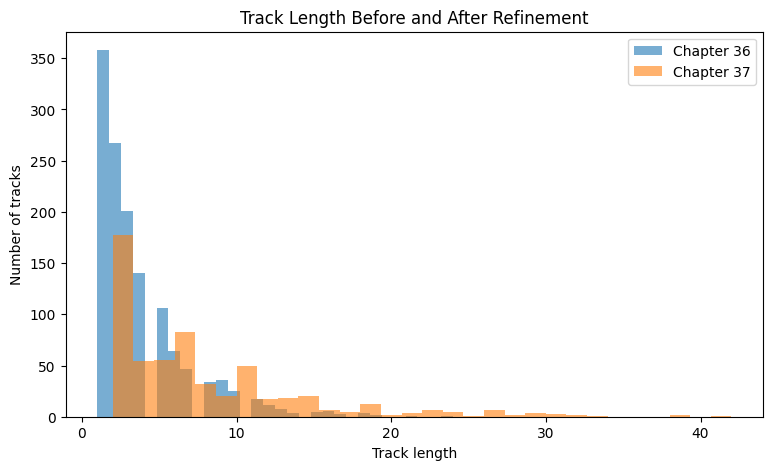

In [12]:
plt.figure(figsize=(9,5))
plt.hist(filtered_track_nodes_df.groupby('track_id').size(),bins=30,alpha=.6,label='Chapter 36')
plt.hist(refined_track_nodes_df.groupby('track_id').size(),bins=30,alpha=.6,label='Chapter 37')
plt.title('Track Length Before and After Refinement'); plt.xlabel('Track length'); plt.ylabel('Number of tracks'); plt.legend(); plt.show()

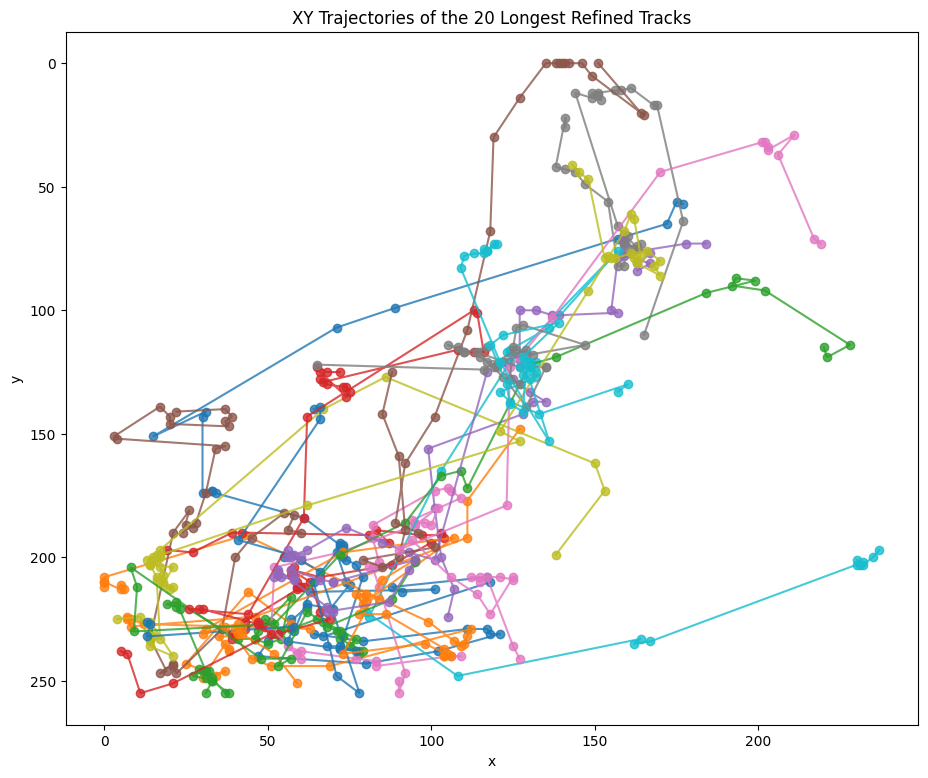

In [13]:
def plot_longest_tracks(nodes,summary,n=20):
    plt.figure(figsize=(11,9))
    for track_id in summary.head(n).track_id:
        g=nodes[nodes.track_id==track_id].sort_values('t')
        plt.plot(g.x,g.y,marker='o',alpha=.8)
    plt.gca().invert_yaxis(); plt.title(f'XY Trajectories of the {n} Longest Refined Tracks'); plt.xlabel('x'); plt.ylabel('y'); plt.show()
plot_longest_tracks(refined_track_nodes_df,refined_track_summary_df)

## Step 9 — Ground-Truth Validation

In [14]:
def load_gt(sample_id):
    path=Path('/kaggle/input/competitions/biohub-cell-tracking-during-development/train')/f'{sample_id}.geff'
    if not path.exists(): print('GT not found; validation skipped.'); return None,None
    g=zarr.open(path,mode='r')
    nodes=pd.DataFrame({'gt_node_id':g['nodes/ids'][:],'t':g['nodes/props/t/values'][:],'z':g['nodes/props/z/values'][:],'y':g['nodes/props/y/values'][:],'x':g['nodes/props/x/values'][:]})
    e=np.asarray(g['edges/ids'][:]) if 'edges/ids' in g else np.empty((0,2))
    edges=pd.DataFrame({'gt_source':e[:,0],'gt_target':e[:,1]}) if len(e) else pd.DataFrame(columns=['gt_source','gt_target'])
    return nodes,edges

def match_nodes(nodes,gt,radius):
    out=[]
    for t in sorted(nodes.t.unique()):
        p=nodes[nodes.t==t].reset_index(drop=True); g=gt[gt.t==t].reset_index(drop=True)
        if p.empty or g.empty: continue
        d=cdist(p[['z','y','x']].to_numpy(np.float32),g[['z','y','x']].to_numpy(np.float32))
        pi,gi=linear_sum_assignment(np.where(d<=radius,d,1e9))
        for a,b in zip(pi,gi):
            if d[a,b]<=radius: out.append({'detection_id':p.iloc[a].detection_id,'track_id':int(p.iloc[a].track_id),'t':int(t),'gt_node_id':g.iloc[b].gt_node_id,'match_distance':float(d[a,b])})
    return pd.DataFrame(out)

def evaluate_links(edges,matches,gt_edges):
    sm=matches[['detection_id','gt_node_id']].rename(columns={'detection_id':'source_detection_id','gt_node_id':'matched_gt_source'})
    tm=matches[['detection_id','gt_node_id']].rename(columns={'detection_id':'target_detection_id','gt_node_id':'matched_gt_target'})
    ev=edges.merge(sm,on='source_detection_id',how='left').merge(tm,on='target_detection_id',how='left')
    true=set(zip(gt_edges.gt_source,gt_edges.gt_target))
    ev['both_nodes_matched']=ev.matched_gt_source.notna()&ev.matched_gt_target.notna()
    ev['correct_link']=[(a,b) in true if pd.notna(a) and pd.notna(b) else False for a,b in zip(ev.matched_gt_source,ev.matched_gt_target)]
    s=ev.groupby('edge_type',as_index=False).agg(predicted_links=('correct_link','size'),both_nodes_matched=('both_nodes_matched','sum'),correct_links=('correct_link','sum'))
    s['precision_all']=s.correct_links/s.predicted_links.clip(lower=1); s['precision_matched_only']=s.correct_links/s.both_nodes_matched.clip(lower=1)
    return ev,s

gt_nodes_df,gt_edges_df=load_gt(CONFIG.sample_id)
if gt_nodes_df is not None:
    refined_node_matches_df=match_nodes(refined_track_nodes_df,gt_nodes_df,CONFIG.node_match_radius)
    refined_evaluated_links_df,refined_link_summary_df=evaluate_links(refined_track_edges_df,refined_node_matches_df,gt_edges_df)
    print('matched nodes',len(refined_node_matches_df)); display(refined_link_summary_df)
else:
    refined_node_matches_df=pd.DataFrame(); refined_evaluated_links_df=pd.DataFrame(); refined_link_summary_df=pd.DataFrame()

matched nodes 294


,edge_type,predicted_links,both_nodes_matched,correct_links,precision_all,precision_matched_only
0,gap_closing,391,4,1,0.002558,0.250000
1,original,2971,91,67,0.022551,0.736264


## Step 10 — Validate and Save Outputs

In [15]:
def validate(nodes,edges):
    if nodes.detection_id.duplicated().any(): raise ValueError('Duplicate detection in refined tracks.')
    if not edges.empty:
        if edges.target_detection_id.duplicated().any(): raise ValueError('A detection has more than one parent.')
        if not (edges.target_t>edges.source_t).all(): raise ValueError('Edges must move forward in time.')
    rows=[]
    for track_id,g in nodes.groupby('track_id'):
        ts=np.sort(g.t.to_numpy()); rows.append({'track_id':int(track_id),'num_nodes':len(g),'start_t':int(ts[0]),'end_t':int(ts[-1]),'unique_timepoints':len(ts)==len(np.unique(ts)),'strictly_increasing':bool(np.all(np.diff(ts)>0)) if len(ts)>1 else True})
    v=pd.DataFrame(rows)
    if not v[['unique_timepoints','strictly_increasing']].all().all(): raise ValueError('Invalid refined time ordering.')
    return v

refined_validation_df=validate(refined_track_nodes_df,refined_track_edges_df)
print('Refined output validation passed.'); display(refined_validation_df.head())

out=Path('/kaggle/working')
outputs={
'refined_track_nodes':out/'chapter37_refined_track_nodes.csv',
'refined_track_edges':out/'chapter37_refined_track_edges.csv',
'refined_track_summary':out/'chapter37_refined_track_summary.csv',
'gap_closing_links':out/'chapter37_gap_closing_links.csv',
'validation':out/'chapter37_output_validation.csv',
'comparison':out/'chapter37_before_after_comparison.csv',
'node_matches':out/'chapter37_gt_node_matches.csv',
'evaluated_links':out/'chapter37_evaluated_links.csv',
'link_summary':out/'chapter37_link_summary.csv'}
refined_track_nodes_df.to_csv(outputs['refined_track_nodes'],index=False)
refined_track_edges_df.to_csv(outputs['refined_track_edges'],index=False)
refined_track_summary_df.to_csv(outputs['refined_track_summary'],index=False)
gap_links_df.to_csv(outputs['gap_closing_links'],index=False)
refined_validation_df.to_csv(outputs['validation'],index=False)
comparison_df.to_csv(outputs['comparison'],index=False)
if not refined_node_matches_df.empty: refined_node_matches_df.to_csv(outputs['node_matches'],index=False)
if not refined_evaluated_links_df.empty: refined_evaluated_links_df.to_csv(outputs['evaluated_links'],index=False)
if not refined_link_summary_df.empty: refined_link_summary_df.to_csv(outputs['link_summary'],index=False)
for k,p in outputs.items():
    if p.exists(): print('Saved',k,':',p)

Refined output validation passed.


,track_id,num_nodes,start_t,end_t,unique_timepoints,strictly_increasing
0,0,4,0,6,True,True
1,1,10,0,19,True,True
2,2,7,0,11,True,True
3,3,9,0,13,True,True
4,4,27,0,47,True,True


Saved refined_track_nodes : /kaggle/working/chapter37_refined_track_nodes.csv
Saved refined_track_edges : /kaggle/working/chapter37_refined_track_edges.csv
Saved refined_track_summary : /kaggle/working/chapter37_refined_track_summary.csv
Saved gap_closing_links : /kaggle/working/chapter37_gap_closing_links.csv
Saved validation : /kaggle/working/chapter37_output_validation.csv
Saved comparison : /kaggle/working/chapter37_before_after_comparison.csv
Saved node_matches : /kaggle/working/chapter37_gt_node_matches.csv
Saved evaluated_links : /kaggle/working/chapter37_evaluated_links.csv
Saved link_summary : /kaggle/working/chapter37_link_summary.csv


# What to Save

Before Chapter 38, save these required outputs:

```text
chapter37_refined_track_nodes.csv
chapter37_refined_track_edges.csv
```

Strongly recommended:

```text
chapter37_refined_track_summary.csv
chapter37_gap_closing_links.csv
```

Use **Save Version → Save & Run All (Commit)** to preserve `/kaggle/working` outputs.